In [1]:
import os
import sys
from pathlib import Path

_cwd = Path.cwd()
ROOT = _cwd if (_cwd / "scripts").is_dir() else _cwd.parent
sys.path.insert(0, str(ROOT / "scripts"))

from notebook_setup import bootstrap

ROOT, DATA_DIR, PAPER_DIR = bootstrap()

In [2]:
import pandas as pd
from FinMind.data import DataLoader
import os
api = DataLoader()
api.login_by_token(api_token=os.environ["FINMIND_TOKEN"])

df = pd.read_csv(DATA_DIR / "TSMC_stock_data.csv")

df = df.sort_values(["stock_id", "date"])

def calc_ma(x, window):
    return x.rolling(window=window).mean()

# MA50
df["MA_50"] = (
    df.groupby("stock_id")["close"]
      .transform(lambda x: calc_ma(x, 50))
)

# MA120
df["MA_120"] = (
    df.groupby("stock_id")["close"]
      .transform(lambda x: calc_ma(x, 120))
)

df["volume_ma_20"] = (
    df.groupby("stock_id")["Trading_Volume"]
      .transform(lambda x: calc_ma(x,20))
)

# 📈 20日報酬率（動能）
df["momentum_20"] = (
    df.groupby("stock_id")["close"]
      .transform(lambda x: x.pct_change(20))
)

df["momentum_60"] = (
    df.groupby("stock_id")["close"]
      .transform(lambda x: x.pct_change(60))
)

df["momentum_120"] = (
    df.groupby("stock_id")["close"]
      .transform(lambda x: x.pct_change(120))
)


market = api.taiwan_stock_daily(
    stock_id="0050",
    start_date="2010-01-01",
    end_date="2026-12-31",
)
market = market.sort_values("date").reset_index(drop=True)
from backtest_portfolio import prepare_market_df, SPLIT_0050_EFFECTIVE, SPLIT_0050_RATIO

market = prepare_market_df(market.rename(columns={"close": "market_close_raw"}))
market["MA200"] = market["market_close"].rolling(window=200).mean()
# 只留大盤欄位，避免跟個股 close 撞名
market_sub = market[["date", "market_close", "market_close_raw", "MA200"]].rename(
    columns={"MA200": "market_MA200"}
)
market_sub["date"] = pd.to_datetime(market_sub["date"])
# 合併進 df
df["date"] = pd.to_datetime(df["date"])
df = df.merge(market_sub, on="date", how="left")
# 大盤濾網（用分割還原價與 MA200，避免 2025/6 假跌破）
df["market_bull"] = df["market_close"] > df["market_MA200"]
df.to_csv(DATA_DIR / "all_stock_with_MA50_MA120_return20.csv", index=False)
print(f"0050 分割還原: {SPLIT_0050_RATIO:.0f}拆1，生效日 {SPLIT_0050_EFFECTIVE.date()}")



2026-07-01 15:50:42.750 | INFO     | FinMind.data.finmind_api:login_by_token:85 - Login success
2026-07-01 15:50:42.835 | INFO     | FinMind.data.finmind_api:login_by_token:85 - Login success
2026-07-01 15:50:43.005 | INFO     | FinMind.data.finmind_api:get_data:166 - download Dataset.TaiwanStockPrice, data_id: 0050


0050 分割還原: 4拆1，生效日 2025-06-18


In [3]:
# ── 策略參數（固定，不做樣本內優化，降低 overfit）──
TOP_K = 5                 # 股票池 ~50 檔 → 前 50%，不從 IS 挑最優 K
VOLUME_SURGE_MULT = 1.2    # 放量門檻（原 1.5 過嚴，OOS 訊號太少）

# ── 定期定額（對齊 paper_trading/settings.csv）──
from backtest_portfolio import (
    DCA_AMOUNT, DCA_0050_WEIGHT, DCA_STRATEGY_WEIGHT, DCA_START, MAX_POSITIONS,
    STRATEGY_CASH_CAP_MONTHS,
)


def compute_momentum_score(data):
    pool = data[
        (data["MA_50"] > data["MA_120"]) &
        (data["momentum_20"] > 0)
    ].dropna(subset=["momentum_20", "momentum_60", "momentum_120"]).copy()

    pool["score"] = (
        pool.groupby("date")["momentum_20"].rank() * 0.2 +
        pool.groupby("date")["momentum_60"].rank() * 0.3 +
        pool.groupby("date")["momentum_120"].rank() * 0.5
    )
    return pool[["date", "stock_id", "score"]]

daily_scores = compute_momentum_score(df)

# 預覽：最新交易日 top K
latest_date = df["date"].max()
top = (
    daily_scores[daily_scores["date"] == latest_date]
    .merge(df[df["date"] == latest_date], on=["date", "stock_id"])
    .sort_values("score", ascending=False)
    .head(TOP_K)
)
print(f"固定 TOP_K={TOP_K}，放量倍數={VOLUME_SURGE_MULT}")
print(top[[
    "stock_id", "score", "momentum_20", "momentum_60", "momentum_120", "close", "MA_50",
]])



固定 TOP_K=5，放量倍數=1.2
    stock_id  score  momentum_20  momentum_60  momentum_120   close    MA_50
4       2327   28.4     0.347518     3.634146      4.089286  1140.0  666.020
28      8046   25.7     0.363109     1.068662      3.766734  1175.0  903.520
3       2303   25.3     0.194346     2.152985      2.383383   169.0  120.508
1       1303   25.1     0.626667     1.373541      2.182609   183.0  105.816
27      4958   24.9     0.159615     1.824356      3.173010   603.0  487.480


In [4]:
signals = df.copy()
signals = signals.sort_values(["stock_id", "date"]).reset_index(drop=True)

# 前一日資料（記得 groupby）
signals["prev_close"]   = signals.groupby("stock_id")["close"].shift(1)
signals["prev_MA_50"]    = signals.groupby("stock_id")["MA_50"].shift(1)
signals["prev_MA_120"]   = signals.groupby("stock_id")["MA_120"].shift(1)

# ── 買進訊號 ──
signals["volume_surge"] = (
    signals["Trading_Volume"] >= signals["volume_ma_20"] * VOLUME_SURGE_MULT
)

# 動能分數：前一日排名需在固定 TOP_K 內（score 亦用於配倉排序）
signals = signals.merge(daily_scores, on=["date", "stock_id"], how="left")
signals["score_prev"] = signals.groupby("stock_id")["score"].shift(1)
signals["score_rank_prev"] = (
    signals.groupby("date")["score_prev"]
    .rank(ascending=False, method="first")
)
signals["in_top_k"] = signals["score_rank_prev"] <= TOP_K

signals["buy_signal"] = (
    signals["market_bull"]
    & (signals["MA_50"] > signals["MA_120"])
    & (signals["close"] > signals["MA_50"])
    & (signals["momentum_20"] > 0)
    & signals["in_top_k"]
)

# 嚴格版（突破+放量）僅供觀察，不作為回測進場
signals["buy_signal_strict"] = (
    signals["buy_signal"]
    & (signals["prev_close"] <= signals["prev_MA_50"])
    & signals["volume_surge"]
)

# ── 賣出訊號（維持 AND；OR 邏輯在 IS 期明顯變差，故保留原設計）──
signals["sell_ma_trend"] = signals["MA_50"] < signals["MA_120"]
signals["sell_breakdown"] = (
    (signals["close"] < signals["MA_50"]) &
    (signals["prev_close"] >= signals["prev_MA_50"])
)
signals["sell_volume"] = signals["volume_surge"]

signals["sell_signal"] = (
    signals["sell_ma_trend"] &
    signals["sell_breakdown"] &
    signals["sell_volume"]
)

print(f"buy_signal 次數: {signals['buy_signal'].sum()}（趨勢+動能 top K）")
print(f"buy_signal_strict 次數: {signals['buy_signal_strict'].sum()}（另需突破 MA50 + 放量）")
print(signals[[
    "stock_id", "date", "close", "MA_50", "MA_120",
    "score", "score_rank_prev", "in_top_k",
    "buy_signal",
    "sell_ma_trend", "sell_breakdown", "sell_volume", "sell_signal"
]].tail(20))

buy_signal 次數: 12770（趨勢+動能 top K）
buy_signal_strict 次數: 24（另需突破 MA50 + 放量）
        stock_id       date   close   MA_50      MA_120  score  \
187515      8046 2026-06-03   904.0  782.20  533.191667    NaN   
187516      8046 2026-06-04   878.0  789.08  538.287500    NaN   
187517      8046 2026-06-05   845.0  796.16  543.145833    NaN   
187518      8046 2026-06-08   831.0  801.98  547.829167    NaN   
187519      8046 2026-06-09   914.0  808.88  553.291667   25.5   
187520      8046 2026-06-10   847.0  814.60  558.100000    NaN   
187521      8046 2026-06-11   807.0  819.14  562.575000    NaN   
187522      8046 2026-06-12   819.0  825.08  567.033333   27.1   
187523      8046 2026-06-15   860.0  830.80  571.866667   28.9   
187524      8046 2026-06-16   902.0  837.48  577.066667   30.9   
187525      8046 2026-06-17   885.0  842.70  582.179167   32.2   
187526      8046 2026-06-18   874.0  847.44  587.245833   25.0   
187527      8046 2026-06-22   864.0  851.34  592.370833    NaN   
1

In [5]:
from backtest_portfolio import (
    COMMISSION_RATE,
    TAX_RATE,
    MIN_COMMISSION,
    net_return_from_prices,
    DCA_AMOUNT,
    DCA_STRATEGY_WEIGHT,
)

# 交易成本對齊 paper_trading/settings.csv（rate + 最低手續費）
# 組合回測以實際 allocate 逐筆計費；此處用每期策略注入額作參考
REFERENCE_TRADE_CASH = DCA_AMOUNT * DCA_STRATEGY_WEIGHT

# 出場參數
STOP_LOSS_PCT = 0.08         # 硬停損：虧 8% 出場
TRAILING_STOP_PCT = 0.10     # 移動停利：自高點回撤 10% 出場

trades = []

for stock in signals["stock_id"].unique():
    df_s = signals[signals["stock_id"] == stock]

    in_position = False
    entry_price = 0
    entry_date = None
    highest_price = 0

    for i in df_s.index:
        row = df_s.loc[i]

        # 進場
        if (not in_position) and row["buy_signal"]:
            in_position = True
            entry_price = row["close"]
            entry_date = row["date"]
            entry_score = row["score"]
            highest_price = row["close"]

        # 持倉中：每天檢查停損 / 移動停利 / 賣出訊號
        elif in_position:
            highest_price = max(highest_price, row["close"])

            current_return = (row["close"] / entry_price) - 1
            stop_loss_hit = current_return <= -STOP_LOSS_PCT
            trailing_stop_hit = row["close"] < highest_price * (1 - TRAILING_STOP_PCT)
            trend_exit = row["sell_signal"]

            if stop_loss_hit or trailing_stop_hit or trend_exit:
                exit_price = row["close"]
                exit_date = row["date"]

                gross_return = (exit_price / entry_price) - 1
                net_return = net_return_from_prices(
                    REFERENCE_TRADE_CASH, entry_price, exit_price
                )

                if stop_loss_hit:
                    exit_reason = "stop_loss"
                elif trailing_stop_hit:
                    exit_reason = "trailing_stop"
                else:
                    exit_reason = "trend_exit"

                trades.append({
                    "stock_id": stock,
                    "entry_date": entry_date,
                    "exit_date": exit_date,
                    "entry_price": entry_price,
                    "exit_price": exit_price,
                    "score": entry_score,
                    "gross_return": gross_return,
                    "return": net_return,
                    "exit_reason": exit_reason,
                })

                in_position = False
                entry_price = 0
                entry_date = None
                highest_price = 0

In [6]:
import pandas as pd
import numpy as np
from backtest_portfolio import (
    market_df_from_stock_table,
    simulate_portfolio_dca,
    simulate_0050_dca,
    DCA_AMOUNT,
    DCA_0050_WEIGHT,
    DCA_STRATEGY_WEIGHT,
    DCA_START,
    MAX_POSITIONS,
    STRATEGY_CASH_CAP_MONTHS,
)

trades_df = pd.DataFrame(trades)
trades_df["entry_date"] = pd.to_datetime(trades_df["entry_date"])
trades_df["exit_date"] = pd.to_datetime(trades_df["exit_date"])

market_df = market_df_from_stock_table(df)

equity_df, port_metrics = simulate_portfolio_dca(
    trades_df,
    signals,
    market_df,
    dca_amount=DCA_AMOUNT,
    w_0050=DCA_0050_WEIGHT,
    w_strategy=DCA_STRATEGY_WEIGHT,
    dca_start=DCA_START,
    max_positions=MAX_POSITIONS,
    strategy_cash_cap_months=STRATEGY_CASH_CAP_MONTHS,
)

equity_df["peak"] = equity_df["equity"].cummax()
equity_df["drawdown"] = equity_df["equity"] / equity_df["peak"] - 1

xirr = port_metrics["xirr"]
total_invested = port_metrics["total_invested"]
final_equity = port_metrics["final_equity"]
total_return = port_metrics["total_return"]
max_dd = port_metrics["max_dd"]
years = port_metrics["years"]

# 基準 1：同配置但 30% 留現金（策略池不選股）
from backtest_portfolio import simulate_matched_dca_baseline
bench_matched = simulate_matched_dca_baseline(
    market_df,
    w_0050=DCA_0050_WEIGHT,
    w_strategy=DCA_STRATEGY_WEIGHT,
    dca_start=DCA_START,
)

# 基準 2：100% 定額 0050（機會成本參考，配置不同）
_, bench_0050_metrics = simulate_0050_dca(
    market_df,
    dca_amount=DCA_AMOUNT,
    w_0050=1.0,
    dca_start=DCA_START,
)

print("=" * 50)
print(f"投入方式:     定期定額 每期 {DCA_AMOUNT:,.0f} 元")
print(f"配置:         {DCA_0050_WEIGHT:.0%} 0050 / {DCA_STRATEGY_WEIGHT:.0%} 策略")
print(f"扣款起始:     {DCA_START.date()}")
print("-" * 50)
print("【整戶】")
print(f"累計投入（本金）:     {total_invested:,.0f}")
print(f"複利後總資產:         {final_equity:,.0f}  ← 含0050漲幅+交易獲利再投入")
print(f"複利增值（總獲利）:   {port_metrics.get('compound_profit_total', final_equity - total_invested):,.0f}")
print(f"總報酬率:             {total_return:.2%}")
print(f"投資人 XIRR:          {xirr:.2%}")
print(f"XIRR 複利終值驗算:    {port_metrics.get('compound_fv_at_xirr', float('nan')):,.0f}  （應≈複利後總資產）")
print(f"最大回撤:             {max_dd:.2%}")
print(f"回測年數:             {years:.1f} 年")
print("-" * 50)
print("【0050 桶（70% 定額買指數，股價複利）】")
print(f"累計注入:             {port_metrics.get('cumulative_0050_deposits', 0):,.0f}")
print(f"複利後市值:           {port_metrics.get('final_equity_0050', 0):,.0f}")
print(f"複利增值:             {port_metrics.get('compound_profit_0050', 0):+,.0f}")
print("-" * 50)
print("【策略池（30% 現金池 + 選股，獲利再投入）】")
print(f"累計注入:             {port_metrics.get('cumulative_strategy_deposits', 0):,.0f}")
print(f"複利後策略池資產:     {port_metrics.get('final_equity_strategy', 0):,.0f}")
print(f"複利增值:             {port_metrics.get('compound_profit_strategy', 0):+,.0f}")
print(f"  └ 已平倉再投入獲利: {port_metrics.get('strategy_realized_profit', 0):+,.0f}")
print(f"  └ 持倉浮動損益:     {port_metrics.get('strategy_unrealized_pnl', 0):+,.0f}")
print(f"平均持倉檔數:         {port_metrics.get('avg_n_positions', float('nan')):.2f} / {MAX_POSITIONS}")
print(f"平均持股市值占比:     {port_metrics.get('avg_invested_pct', float('nan')):.1f}%")
if STRATEGY_CASH_CAP_MONTHS and STRATEGY_CASH_CAP_MONTHS > 0:
    print(f"方案B 現金上限:     {STRATEGY_CASH_CAP_MONTHS:.0f} 期 × {DCA_STRATEGY_WEIGHT:.0%} 投入 = {port_metrics.get('strategy_cash_cap', 0):,.0f} 元")
    print(f"累計溢出買 0050:     {port_metrics.get('total_swept_to_0050', 0):,.0f}")
else:
    print("方案B 溢出買 0050:  關閉（策略池資金留待選股）")
print(f"平均現金占比:         {port_metrics.get('avg_cash_pct', float('nan')):.1f}%")
print(f"策略交易次數:         {port_metrics['n_trades']} 筆信號 / {port_metrics.get('n_trades_executed', 0)} 筆實際成交")
print(f"勝率（實際成交）:     {port_metrics['win_rate']:.1%}")
print("-" * 50)
print("【基準比較】")
print(f"同配置 70/30（30%留現金）XIRR: {bench_matched['xirr']:.2%}")
print(f"策略 Alpha（vs 同配置）:        {xirr - bench_matched['xirr']:+.2%}  ← 選股是否贏過囤現金")
print(f"100% 0050 定額 XIRR:            {bench_0050_metrics.get('xirr', float('nan')):.2%}  ← 機會成本")
print(f"vs 100% 0050 超額:              {xirr - bench_0050_metrics.get('xirr', 0):+.2%}  ← 負值常見（未全押大盤）")
print("💡 修正 0050 分割後，100% 0050 基準 XIRR 會大幅上升；")
print("   70/30 跑輸 100% 0050 不代表策略無效，請優先看「策略 Alpha」。")
print("=" * 50)







投入方式:     定期定額 每期 5,500 元
配置:         50% 0050 / 50% 策略
扣款起始:     2010-01-11
--------------------------------------------------
【整戶】
累計投入（本金）:     1,061,500
複利後總資產:         6,423,300  ← 含0050漲幅+交易獲利再投入
複利增值（總獲利）:   5,361,800
總報酬率:             505.12%
投資人 XIRR:          19.97%
XIRR 複利終值驗算:    6,423,300  （應≈複利後總資產）
最大回撤:             -23.35%
回測年數:             16.0 年
--------------------------------------------------
【0050 桶（70% 定額買指數，股價複利）】
累計注入:             530,750
複利後市值:           2,796,926
複利增值:             +2,266,176
--------------------------------------------------
【策略池（30% 現金池 + 選股，獲利再投入）】
累計注入:             530,750
複利後策略池資產:     3,626,374
複利增值:             +3,095,624
  └ 已平倉再投入獲利: +3,095,624
  └ 持倉浮動損益:     +0
平均持倉檔數:         3.65 / 5
平均持股市值占比:     72.0%
方案B 溢出買 0050:  關閉（策略池資金留待選股）
平均現金占比:         28.0%
策略交易次數:         924 筆信號 / 395 筆實際成交
勝率（實際成交）:     37.5%
--------------------------------------------------
【基準比較】
同配置 70/30（30%留現金）XIRR: 13.03%
策略 Alpha（vs 同配置）:        +6.94%  ← 選

In [7]:
# ── 個股策略績效表（訊號層級：每檔獨立依策略進出場）──
# 需先執行 Cell5（trades_df）
# import numpy as np
# import pandas as pd
# from backtest_portfolio import xirr as calc_xirr, DCA_AMOUNT, DCA_STRATEGY_WEIGHT

# REFERENCE_TRADE_CASH = DCA_AMOUNT * DCA_STRATEGY_WEIGHT  # 2,750 元/筆參考投入
# DIAG_STOCK = "3017"  # 診斷用：改成想查的股票代碼


# def _stock_xirr(g: pd.DataFrame) -> float:
#     """每檔依實際進出場日期計算 XIRR（每筆參考投入 REFERENCE_TRADE_CASH）。"""
#     flows, dates = [], []
#     for _, row in g.iterrows():
#         flows.append(-REFERENCE_TRADE_CASH)
#         dates.append(row["entry_date"])
#         flows.append(REFERENCE_TRADE_CASH * (1 + row["return"]))
#         dates.append(row["exit_date"])
#     if len(flows) < 2:
#         return np.nan
#     return xirr(flows, dates)


# if trades_df.empty:
#     print("尚無交易紀錄，請先執行 Cell4～5")
# else:
#     _td = trades_df.copy()
#     _td["holding_days"] = (_td["exit_date"] - _td["entry_date"]).dt.days

#     stock_perf = (
#         _td.groupby("stock_id")
#         .agg(
#             交易次數=("return", "count"),
#             勝率=("return", lambda x: (x > 0).mean()),
#             平均報酬=("return", "mean"),
#             累計報酬=("return", lambda x: (1 + x).prod() - 1),
#             平均持有天=("holding_days", "mean"),
#             停損占比=("exit_reason", lambda x: (x == "stop_loss").mean()),
#             移停占比=("exit_reason", lambda x: (x == "trailing_stop").mean()),
#             趨勢出場占比=("exit_reason", lambda x: (x == "trend_exit").mean()),
#             最佳單筆=("return", "max"),
#             最差單筆=("return", "min"),
#         )
#         .assign(XIRR=_td.groupby("stock_id").apply(_stock_xirr, include_groups=False))
#         .sort_values("平均報酬", ascending=False)
#     )

#     traded = len(stock_perf)
#     universe = signals["stock_id"].nunique()
#     total_trades = len(_td)
#     print(f"【個股策略績效】共 {universe} 檔標的，{traded} 檔曾產生交易，合計 {total_trades} 筆")
#     print(f"每筆參考投入：{REFERENCE_TRADE_CASH:,.0f} 元（策略池 50% × 每期 DCA）")
#     print("（每檔獨立回測；平均報酬 / XIRR 較可信，累計報酬為複利假設）\n")

#     display(
#         stock_perf.style.format(
#             {
#                 "勝率": "{:.1%}",
#                 "平均報酬": "{:.2%}",
#                 "累計報酬": "{:.2%}",
#                 "XIRR": "{:.2%}",
#                 "停損占比": "{:.1%}",
#                 "移停占比": "{:.1%}",
#                 "趨勢出場占比": "{:.1%}",
#                 "最佳單筆": "{:.2%}",
#                 "最差單筆": "{:.2%}",
#                 "平均持有天": "{:.0f}",
#             }
#         )
#         .background_gradient(subset=["平均報酬"], cmap="RdYlGn")
#     )

#     # ── 單檔診斷 ──
#     if DIAG_STOCK in _td["stock_id"].astype(str).values:
#         diag = _td[_td["stock_id"].astype(str) == DIAG_STOCK].copy()
#         print(f"\n{'=' * 50}")
#         print(f"【{DIAG_STOCK} 診斷】共 {len(diag)} 筆交易")
#         print(f"平均報酬：{diag['return'].mean():.2%}  |  勝率：{(diag['return'] > 0).mean():.1%}")
#         print(f"XIRR：{_stock_xirr(diag):.2%}  |  累計報酬（複利）：{(1 + diag['return']).prod() - 1:.2%}")
#         print("\n出場原因分佈：")
#         print(diag["exit_reason"].value_counts(normalize=True).rename("占比").to_string())
#         print("\n各出場原因平均報酬：")
#         print(diag.groupby("exit_reason")["return"].mean().map(lambda x: f"{x:.2%}").to_string())
#         print("\n每筆交易明細：")
#         detail = diag[
#             ["entry_date", "exit_date", "entry_price", "exit_price",
#              "return", "exit_reason", "holding_days"]
#         ].copy()
#         detail["return"] = detail["return"].map(lambda v: f"{v:.2%}")
#         detail["entry_date"] = detail["entry_date"].dt.date
#         detail["exit_date"] = detail["exit_date"].dt.date
#         display(detail)
#     else:
#         print(f"\n⚠ DIAG_STOCK={DIAG_STOCK} 無交易紀錄，請改代碼或確認 trades_df")


In [8]:
print(trades_df["exit_reason"].value_counts(normalize=True))
print(f"勝率: {(trades_df['return'] > 0).mean():.1%}")
print(f"平均獲利: {trades_df.loc[trades_df['return']>0, 'return'].mean():.2%}")
print(f"平均虧損: {trades_df.loc[trades_df['return']<=0, 'return'].mean():.2%}")
print(f"交易次數: {len(trades_df)}")
print(f"平均持有天數: {(trades_df['exit_date'] - trades_df['entry_date']).dt.days.mean():.0f}")

exit_reason
trailing_stop    0.630952
stop_loss        0.356061
trend_exit       0.012987
Name: proportion, dtype: float64
勝率: 34.0%
平均獲利: 23.03%
平均虧損: -9.64%
交易次數: 924
平均持有天數: 57


In [9]:
# 0050 定期定額基準（與策略 equity_df 同區間）
from backtest_portfolio import market_df_from_stock_table, simulate_0050_dca, DCA_AMOUNT, DCA_START

market_df = market_df_from_stock_table(df)
eq_start = equity_df["date"].iloc[0]
eq_end = equity_df["date"].iloc[-1]

bench_eq, bench_m = simulate_0050_dca(
    market_df,
    dca_amount=DCA_AMOUNT,
    w_0050=1.0,
    dca_start=DCA_START,
    period_start=eq_start,
    period_end=eq_end,
)

print(f"比較區間: {eq_start.date()} ~ {eq_end.date()}")
print(f"0050 定期定額 XIRR: {bench_m['xirr']:.2%}")
print(f"0050 最大回撤:      {bench_m['max_dd']:.2%}")
print(f"策略 XIRR:          {xirr:.2%}")
print(f"策略 vs 0050:       {xirr - bench_m['xirr']:+.2%} (XIRR)")




比較區間: 2010-07-05 ~ 2026-07-01
0050 定期定額 XIRR: 18.63%
0050 最大回撤:      -34.01%
策略 XIRR:          19.97%
策略 vs 0050:       +1.34% (XIRR)


In [10]:
trades_df = pd.DataFrame(trades)

print("交易次數:", len(trades_df))
print("平均淨報酬:", trades_df["return"].mean())
print("中位數:", trades_df["return"].median())
print("勝率:", (trades_df["return"] > 0).mean())

# 盈虧比
wins = trades_df.loc[trades_df["return"] > 0, "return"]
losses = trades_df.loc[trades_df["return"] <= 0, "return"]
print("平均獲利:", wins.mean())
print("平均虧損:", losses.mean())
print("profit factor:", wins.sum() / abs(losses.sum()))

# 出場原因
print(trades_df["exit_reason"].value_counts(normalize=True))
print(trades_df.groupby("exit_reason")["return"].mean())

交易次數: 924
平均淨報酬: 0.014576451337422823
中位數: -0.05511055052386632
勝率: 0.3398268398268398
平均獲利: 0.23026149333167834
平均虧損: -0.09644830798421034
profit factor: 1.228928219316513
exit_reason
trailing_stop    0.630952
stop_loss        0.356061
trend_exit       0.012987
Name: proportion, dtype: float64
exit_reason
stop_loss       -0.134537
trailing_stop    0.099697
trend_exit      -0.032685
Name: return, dtype: float64


In [11]:
# ── 回測工具 + TOP_K 敏感度（探索用，不用來選參）──
import numpy as np
import pandas as pd
from backtest_portfolio import (
    market_df_from_stock_table,
    simulate_portfolio_dca,
    DCA_AMOUNT,
    DCA_0050_WEIGHT,
    DCA_STRATEGY_WEIGHT,
    DCA_START,
    MAX_POSITIONS,
    STRATEGY_CASH_CAP_MONTHS,
    COMMISSION_RATE,
    TAX_RATE,
    MIN_COMMISSION,
    net_return_from_prices,
)

STOP_LOSS_PCT = 0.08
TRAILING_STOP_PCT = 0.10
REFERENCE_TRADE_CASH = DCA_AMOUNT * DCA_STRATEGY_WEIGHT


def build_signals(data, scores, top_k=None, volume_mult=None):
    """與 Cell4 相同邏輯；top_k / volume_mult 預設用 Cell3 固定參數。"""
    top_k = TOP_K if top_k is None else top_k
    volume_mult = VOLUME_SURGE_MULT if volume_mult is None else volume_mult

    sig = data.copy().sort_values(["stock_id", "date"]).reset_index(drop=True)
    sig["prev_close"] = sig.groupby("stock_id")["close"].shift(1)
    sig["prev_MA_50"] = sig.groupby("stock_id")["MA_50"].shift(1)
    sig["volume_surge"] = sig["Trading_Volume"] >= sig["volume_ma_20"] * volume_mult
    sig = sig.merge(scores, on=["date", "stock_id"], how="left")
    sig["score_prev"] = sig.groupby("stock_id")["score"].shift(1)
    sig["score_rank_prev"] = (
        sig.groupby("date")["score_prev"].rank(ascending=False, method="first")
    )
    sig["in_top_k"] = sig["score_rank_prev"] <= top_k
    sig["buy_signal"] = (
        sig["market_bull"]
        & (sig["MA_50"] > sig["MA_120"])
        & (sig["close"] > sig["MA_50"])
        & (sig["momentum_20"] > 0)
        & sig["in_top_k"]
    )
    sig["sell_signal"] = (
        (sig["MA_50"] < sig["MA_120"])
        & ((sig["close"] < sig["MA_50"]) & (sig["prev_close"] >= sig["prev_MA_50"]))
        & sig["volume_surge"]
    )
    return sig


build_signals_with_top_k = build_signals


def collect_trades(sig):
    trade_list = []
    for stock in sig["stock_id"].unique():
        df_s = sig[sig["stock_id"] == stock]
        in_position = False
        entry_price = entry_date = entry_score = highest_price = 0

        for i in df_s.index:
            row = df_s.loc[i]
            if (not in_position) and row["buy_signal"]:
                in_position = True
                entry_price = row["close"]
                entry_date = row["date"]
                entry_score = row["score"]
                highest_price = row["close"]
            elif in_position:
                highest_price = max(highest_price, row["close"])
                current_return = (row["close"] / entry_price) - 1
                stop_loss_hit = current_return <= -STOP_LOSS_PCT
                trailing_stop_hit = row["close"] < highest_price * (1 - TRAILING_STOP_PCT)
                trend_exit = row["sell_signal"]

                if stop_loss_hit or trailing_stop_hit or trend_exit:
                    exit_price = row["close"]
                    gross_return = (exit_price / entry_price) - 1
                    net_return = net_return_from_prices(
                        REFERENCE_TRADE_CASH, entry_price, exit_price
                    )
                    if stop_loss_hit:
                        exit_reason = "stop_loss"
                    elif trailing_stop_hit:
                        exit_reason = "trailing_stop"
                    else:
                        exit_reason = "trend_exit"
                    trade_list.append({
                        "stock_id": stock,
                        "entry_date": entry_date,
                        "exit_date": row["date"],
                        "entry_price": entry_price,
                        "exit_price": exit_price,
                        "score": entry_score,
                        "gross_return": gross_return,
                        "return": net_return,
                        "exit_reason": exit_reason,
                    })
                    in_position = False
    return trade_list


def simulate_portfolio(trade_list, sig, period_start=None, period_end=None):
    """定期定額回測 wrapper；回傳 metrics（含 xirr）。"""
    tdf = pd.DataFrame(trade_list)
    if tdf.empty:
        return {
            "n_trades": 0, "win_rate": np.nan, "total_return": 0.0,
            "xirr": np.nan, "max_dd": 0.0, "years": 0.0, "avg_cash_pct": 100.0,
            "total_invested": 0.0, "final_equity": 0.0,
        }

    if period_start is not None or period_end is not None:
        tdf["entry_date"] = pd.to_datetime(tdf["entry_date"])
        mask = pd.Series(True, index=tdf.index)
        if period_start is not None:
            mask &= tdf["entry_date"] >= period_start
        if period_end is not None:
            mask &= tdf["entry_date"] <= period_end
        tdf = tdf[mask].reset_index(drop=True)
        if tdf.empty:
            return {
                "n_trades": 0, "win_rate": np.nan, "total_return": 0.0,
                "xirr": np.nan, "max_dd": 0.0, "years": 0.0, "avg_cash_pct": 100.0,
                "total_invested": 0.0, "final_equity": 0.0,
            }

    market_df = market_df_from_stock_table(df)
    _, metrics = simulate_portfolio_dca(
        tdf,
        sig,
        market_df,
        dca_amount=DCA_AMOUNT,
        w_0050=DCA_0050_WEIGHT,
        w_strategy=DCA_STRATEGY_WEIGHT,
        dca_start=DCA_START,
        max_positions=MAX_POSITIONS,
        strategy_cash_cap_months=STRATEGY_CASH_CAP_MONTHS,
        period_start=period_start,
        period_end=period_end,
    )
    return metrics


market_df = market_df_from_stock_table(df)

print("⚠️  以下敏感度僅供探索，正式驗證請用 Cell11（固定 TOP_K，不在 IS 挑參）\n")
print(f"定期定額: 每期 {DCA_AMOUNT:,.0f} 元 | {DCA_0050_WEIGHT:.0%} 0050 / {DCA_STRATEGY_WEIGHT:.0%} 策略\n")
results = []
for k in [5,10, 15, 20, 25, 30, 35, 40,45,50]:
    sig_k = build_signals(df, daily_scores, top_k=k)
    trades_k = collect_trades(sig_k)
    metrics = simulate_portfolio(trades_k, sig_k)
    results.append({"TOP_K": k, **metrics})
    print(f"TOP_K={k:2d}  交易={metrics['n_trades']:3d}  "
          f"XIRR={metrics['xirr']:6.2%}  回撤={metrics['max_dd']:7.2%}  "
          f"勝率={metrics['win_rate']:.1%}  現金占比={metrics['avg_cash_pct']:.1f}%")

sensitivity_df = pd.DataFrame(results)
print("\n" + "=" * 70)
display(sensitivity_df.style.format({
    "win_rate": "{:.1%}",
    "total_return": "{:.2%}",
    "xirr": "{:.2%}",
    "max_dd": "{:.2%}",
    "years": "{:.1f}",
    "avg_cash_pct": "{:.1f}%",
}))




⚠️  以下敏感度僅供探索，正式驗證請用 Cell11（固定 TOP_K，不在 IS 挑參）

定期定額: 每期 5,500 元 | 50% 0050 / 50% 策略

TOP_K= 5  交易=924  XIRR=19.97%  回撤=-23.35%  勝率=37.5%  現金占比=28.0%
TOP_K=10  交易=1252  XIRR=19.05%  回撤=-25.01%  勝率=39.1%  現金占比=29.0%
TOP_K=15  交易=1453  XIRR=20.85%  回撤=-28.98%  勝率=38.9%  現金占比=29.3%
TOP_K=20  交易=1560  XIRR=20.38%  回撤=-25.09%  勝率=39.0%  現金占比=28.8%
TOP_K=25  交易=1604  XIRR=19.90%  回撤=-23.60%  勝率=38.2%  現金占比=29.2%
TOP_K=30  交易=1616  XIRR=20.26%  回撤=-27.69%  勝率=38.0%  現金占比=29.4%
TOP_K=35  交易=1622  XIRR=19.99%  回撤=-27.07%  勝率=38.2%  現金占比=28.8%
TOP_K=40  交易=1625  XIRR=19.89%  回撤=-27.75%  勝率=37.9%  現金占比=29.2%
TOP_K=45  交易=1624  XIRR=19.89%  回撤=-27.75%  勝率=37.9%  現金占比=29.2%
TOP_K=50  交易=1624  XIRR=19.89%  回撤=-27.75%  勝率=37.9%  現金占比=29.2%



,TOP_K,total_invested,total_return,xirr,max_dd,years,final_equity,compound_profit_total,compound_fv_at_xirr,n_trades,n_trades_executed,win_rate,avg_cash_pct,avg_invested_pct,avg_n_positions,final_equity_0050,final_equity_strategy,cumulative_0050_deposits,cumulative_strategy_deposits,compound_profit_0050,compound_profit_strategy,strategy_realized_profit,strategy_unrealized_pnl,strategy_cash_cap,total_swept_to_0050
0,5,1061500.000000,505.12%,19.97%,-23.35%,16.0,6423300.314961,5361800.314961,6423300.314961,924,395,37.5%,28.0%,71.968991,3.649911,2796926.024475,3626374.290486,530750.000000,530750.000000,2266176.024475,3095624.290486,3095624.290486,0.000000,0.000000,0.000000
1,10,1061500.000000,454.27%,19.05%,-25.01%,16.0,5883557.101694,4822057.101694,5883557.101694,1252,353,39.1%,29.0%,71.028710,3.637663,2796926.024475,3086631.077220,530750.000000,530750.000000,2266176.024475,2555881.077220,2555881.077220,0.000000,0.000000,0.000000
2,15,1061500.000000,558.58%,20.85%,-28.98%,16.0,6990842.455156,5929342.455156,6990842.455156,1453,368,38.9%,29.3%,70.695249,3.642766,2796926.024475,4193916.430681,530750.000000,530750.000000,2266176.024475,3663166.430681,3663166.430681,0.000000,0.000000,0.000000
3,20,1061500.000000,529.80%,20.38%,-25.09%,16.0,6685342.606543,5623842.606543,6685342.606543,1560,362,39.0%,28.8%,71.247644,3.627711,2796926.024475,3888416.582068,530750.000000,530750.000000,2266176.024475,3357666.582068,3357666.582068,0.000000,0.000000,0.000000
4,25,1061500.000000,501.13%,19.90%,-23.60%,16.0,6380978.305886,5319478.305886,6380978.305886,1604,361,38.2%,29.2%,70.756084,3.600153,2796926.024475,3584052.281411,530750.000000,530750.000000,2266176.024475,3053302.281411,3053302.281411,0.000000,0.000000,0.000000
5,30,1061500.000000,522.35%,20.26%,-27.69%,16.0,6606231.312790,5544731.312790,6606231.312790,1616,376,38.0%,29.4%,70.583871,3.578719,2796926.024475,3809305.288315,530750.000000,530750.000000,2266176.024475,3278555.288315,3278555.288315,0.000000,0.000000,0.000000
6,35,1061500.000000,506.78%,19.99%,-27.07%,16.0,6441016.911126,5379516.911126,6441016.911126,1622,353,38.2%,28.8%,71.231556,3.617249,2796926.024475,3644090.886651,530750.000000,530750.000000,2266176.024475,3113340.886651,3113340.886651,0.000000,0.000000,0.000000
7,40,1061500.000000,500.74%,19.89%,-27.75%,16.0,6376895.222717,5315395.222717,6376895.222717,1625,359,37.9%,29.2%,70.837544,3.592753,2796926.024475,3579969.198242,530750.000000,530750.000000,2266176.024475,3049219.198242,3049219.198242,0.000000,0.000000,0.000000
8,45,1061500.000000,500.74%,19.89%,-27.75%,16.0,6376895.222717,5315395.222717,6376895.222717,1624,359,37.9%,29.2%,70.837544,3.592753,2796926.024475,3579969.198242,530750.000000,530750.000000,2266176.024475,3049219.198242,3049219.198242,0.000000,0.000000,0.000000
9,50,1061500.000000,500.74%,19.89%,-27.75%,16.0,6376895.222717,5315395.222717,6376895.222717,1624,359,37.9%,29.2%,70.837544,3.592753,2796926.024475,3579969.198242,530750.000000,530750.000000,2266176.024475,3049219.198242,3049219.198242,0.000000,0.000000,0.000000


In [12]:
# ── 樣本內 / 樣本外驗證（固定參數，不在 IS 挑 TOP_K）──
import numpy as np
from backtest_portfolio import market_df_from_stock_table, simulate_0050_dca, DCA_AMOUNT, DCA_START

IS_END = pd.Timestamp("2020-12-31")
OOS_START = pd.Timestamp("2021-01-01")

print(f"固定參數: TOP_K={TOP_K}, 放量={VOLUME_SURGE_MULT}x")
print(f"定期定額: 每期 {DCA_AMOUNT:,.0f} 元\n")


def run_backtest_for_period(data, scores, period_start=None, period_end=None):
    """回測並只計算 entry_date 落在 [period_start, period_end] 的交易。"""
    sig = build_signals(data, scores)
    all_trades = collect_trades(sig)
    metrics = simulate_portfolio(
        all_trades, sig, period_start=period_start, period_end=period_end,
    )
    return metrics, sig


def print_metrics(label, m):
    if not m or m.get("n_trades", 0) == 0 and m.get("total_invested", 0) == 0:
        print(f"{label}: 無交易")
        return
    print(f"--- {label} ---")
    print(f"  交易次數:     {m['n_trades']}")
    print(f"  累計投入:     {m.get('total_invested', 0):,.0f}")
    print(f"  XIRR:         {m['xirr']:.2%}")
    print(f"  總報酬:       {m['total_return']:.2%}")
    print(f"  最大回撤:     {m['max_dd']:.2%}")
    print(f"  勝率:         {m['win_rate']:.1%}")
    print(f"  平均現金占比: {m['avg_cash_pct']:.1f}%")


market_df = market_df_from_stock_table(df)


def print_vs_0050(m, period_label, period_start=None, period_end=None):
    """同區間 100% 0050 定額 XIRR，對齊 Cell6 基準比較。"""
    _, bh = simulate_0050_dca(
        market_df,
        dca_amount=DCA_AMOUNT,
        w_0050=1.0,
        dca_start=DCA_START,
        period_start=period_start,
        period_end=period_end,
    )
    strat_xirr = m.get("xirr") if m else np.nan
    bench_xirr = bh.get("xirr")
    if bench_xirr is not None and strat_xirr is not None and not np.isnan(strat_xirr):
        print(f"\n0050 {period_label} XIRR:  {bench_xirr:.2%}")
        print(f"策略 vs 0050:   {strat_xirr - bench_xirr:+.2%} ({period_label} XIRR)")


print("=" * 70)
is_metrics, _ = run_backtest_for_period(df, daily_scores, period_end=IS_END)
print_metrics("IS 2010～2020", is_metrics)
print_vs_0050(is_metrics, "IS", period_end=IS_END)

print("\n" + "=" * 70)
print("【樣本外 Out-of-Sample】2021～2026 — 固定參數驗證")
print("=" * 70)
oos_metrics, _ = run_backtest_for_period(df, daily_scores, period_start=OOS_START)
print_metrics("OOS 2021～2026", oos_metrics)
print_vs_0050(oos_metrics, "OOS", period_start=OOS_START)

print("\n" + "=" * 70)
print("【全段參考】2010～2026")
print("=" * 70)
full_metrics, _ = run_backtest_for_period(df, daily_scores)
print_metrics("全段", full_metrics)
print_vs_0050(full_metrics, "全段")

if is_metrics and oos_metrics:
    gap = is_metrics["xirr"] - oos_metrics["xirr"]
    _, bh_oos = simulate_0050_dca(
        market_df,
        dca_amount=DCA_AMOUNT,
        w_0050=1.0,
        dca_start=DCA_START,
        period_start=OOS_START,
    )
    print("\n" + "=" * 70)
    print("【Overfit 診斷】")
    print("=" * 70)
    print(f"  IS XIRR - OOS XIRR = {gap:+.2%}")
    if abs(gap) <= 0.03:
        print("  → IS/OOS 差距 ≤ 3%，參數穩定度尚可")
    elif gap > 0.03:
        print("  → OOS 明顯弱於 IS，可能仍有 overfit 或市場環境改變")
    if oos_metrics["xirr"] > bh_oos.get("xirr", -999):
        print("  → OOS 仍贏 0050 DCA，策略具備一定 edge")




固定參數: TOP_K=5, 放量=1.2x
定期定額: 每期 5,500 元

--- IS 2010～2020 ---
  交易次數:     545
  累計投入:     698,500
  XIRR:         7.00%
  總報酬:       46.25%
  最大回撤:     -23.35%
  勝率:         30.5%
  平均現金占比: 31.8%

0050 IS XIRR:  11.04%
策略 vs 0050:   -4.04% (IS XIRR)

【樣本外 Out-of-Sample】2021～2026 — 固定參數驗證
--- OOS 2021～2026 ---
  交易次數:     379
  累計投入:     363,000
  XIRR:         48.41%
  總報酬:       259.32%
  最大回撤:     -16.65%
  勝率:         43.0%
  平均現金占比: 25.6%

0050 OOS XIRR:  39.16%
策略 vs 0050:   +9.26% (OOS XIRR)

【全段參考】2010～2026
--- 全段 ---
  交易次數:     924
  累計投入:     1,061,500
  XIRR:         19.97%
  總報酬:       505.12%
  最大回撤:     -23.35%
  勝率:         37.5%
  平均現金占比: 28.0%

0050 全段 XIRR:  18.56%
策略 vs 0050:   +1.41% (全段 XIRR)

【Overfit 診斷】
  IS XIRR - OOS XIRR = -41.41%
  → OOS 仍贏 0050 DCA，策略具備一定 edge


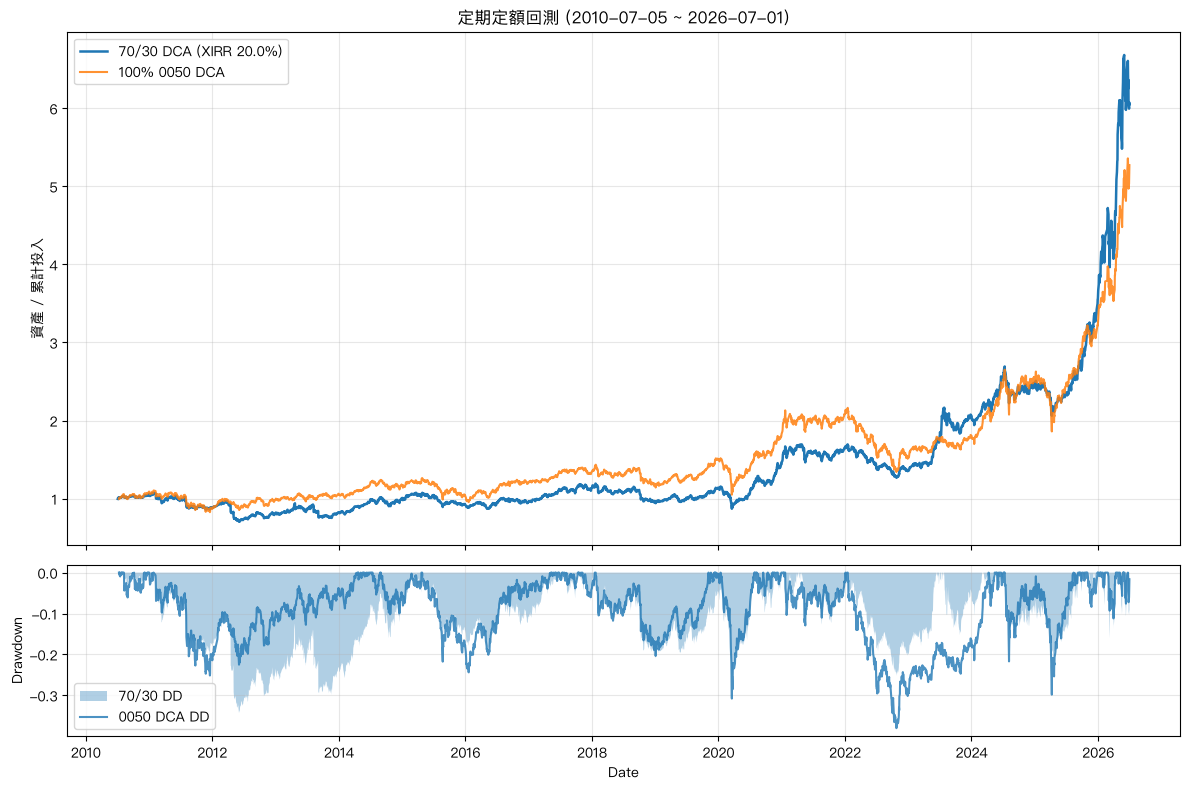


年度報酬對照（帳戶市值）：


,策略,0050 DCA,超額
year,,,
2010,645.40%,inf%,-inf%
2011,126.94%,142.65%,-15.72%
2012,49.25%,88.49%,-39.24%
2013,39.82%,49.72%,-9.90%
2014,56.31%,42.71%,13.61%
2015,11.69%,8.64%,3.05%
2016,23.82%,40.18%,-16.35%
2017,35.94%,27.58%,8.37%
2018,-3.67%,0.58%,-4.25%


In [13]:
# ── 策略淨值 vs 0050（定期定額）──
# 需先執行 Cell6（產生 equity_df、xirr）
import matplotlib.pyplot as plt
from backtest_portfolio import market_df_from_stock_table, simulate_0050_dca, DCA_AMOUNT, DCA_START

plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

eq = equity_df.copy()
eq["date"] = pd.to_datetime(eq["date"])
eq["strategy_norm"] = eq["equity"] / eq["cumulative_invested"]

market_df = market_df_from_stock_table(df)
bench_eq, _ = simulate_0050_dca(
    market_df,
    dca_amount=DCA_AMOUNT,
    w_0050=1.0,
    dca_start=DCA_START,
    period_start=eq["date"].min(),
    period_end=eq["date"].max(),
)
bench_eq = bench_eq.rename(columns={"equity": "benchmark_equity"})
bench_eq["benchmark_norm"] = bench_eq["benchmark_equity"] / bench_eq["cumulative_invested"]

merged = pd.merge_asof(
    eq.sort_values("date"),
    bench_eq[["date", "benchmark_norm", "benchmark_equity"]].sort_values("date"),
    on="date",
    direction="backward",
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

axes[0].plot(merged["date"], merged["strategy_norm"],
             label=f"70/30 DCA (XIRR {xirr:.1%})", linewidth=1.8)
axes[0].plot(merged["date"], merged["benchmark_norm"],
             label="100% 0050 DCA", linewidth=1.5, alpha=0.85)
axes[0].set_ylabel("資產 / 累計投入")
axes[0].set_title(f"定期定額回測 ({eq['date'].min().date()} ~ {eq['date'].max().date()})")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

merged["strat_dd"] = merged["strategy_norm"] / merged["strategy_norm"].cummax() - 1
merged["bench_dd"] = merged["benchmark_norm"] / merged["benchmark_norm"].cummax() - 1
axes[1].fill_between(merged["date"], merged["strat_dd"], 0, alpha=0.35, label="70/30 DD")
axes[1].plot(merged["date"], merged["bench_dd"], label="0050 DCA DD", alpha=0.8)
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

eq["year"] = eq["date"].dt.year
annual_strategy = (
    eq.sort_values("date")
    .groupby("year")["equity"]
    .agg(first="first", last="last")
    .assign(策略=lambda x: x["last"] / x["first"] - 1)["策略"]
)

bench_eq["year"] = bench_eq["date"].dt.year
annual_0050 = (
    bench_eq.sort_values("date")
    .groupby("year")["benchmark_equity"]
    .agg(first="first", last="last")
    .assign(**{"0050 DCA": lambda x: x["last"] / x["first"] - 1})["0050 DCA"]
)

annual = pd.concat([annual_strategy, annual_0050], axis=1)
annual["超額"] = annual["策略"] - annual["0050 DCA"]
print("\n年度報酬對照（帳戶市值）：")
display(annual.style.format("{:.2%}"))




In [14]:
# ── 今日候選股 ──
# 需先執行 Cell 1～3（df、signals、daily_scores）
latest_date = signals["date"].max()
today = signals[signals["date"] == latest_date].copy()

# 大盤狀態
mkt_row = today[["market_close_raw", "market_MA200", "market_bull"]].dropna(subset=["market_MA200"]) if "market_close_raw" in today.columns else today[["market_close", "market_MA200", "market_bull"]].dropna().drop_duplicates()
if not mkt_row.empty:
    mc = mkt_row.iloc[0]
    print(f"資料最新交易日: {latest_date.date()}")
    print(f"0050 收盤: {mc.get('market_close_raw', mc.get('market_close', float('nan'))):.2f}  |  MA200: {mc['market_MA200']:.2f}")
    print(f"大盤濾網 market_bull: {'✅ 多頭（可做多）' if mc['market_bull'] else '❌ 空頭（策略不進場）'}")
else:
    print(f"資料最新交易日: {latest_date.date()}（無大盤資料）")

# ── 1. 今日 buy_signal（符合全部進場條件）──
buys = today[today["buy_signal"]].sort_values("score", ascending=False)
print(f"\n{'='*60}")
print(f"【今日 buy_signal】共 {len(buys)} 檔 — 符合全部進場條件")
print(f"{'='*60}")
if buys.empty:
    print("（無）")
else:
    display(buys[[
        "stock_id", "close", "MA_50", "MA_120",
        "score", "score_rank_prev", "momentum_20", "momentum_60",
        "volume_surge",
    ]].reset_index(drop=True))

# ── 2. 動能 watchlist（前日 top K，今日尚未突破但值得觀察）──
watch = today[
    today["in_top_k"] &
    (today["MA_50"] > today["MA_120"]) &
    (today["momentum_20"] > 0) &
    ~today["buy_signal"]
].sort_values("score_rank_prev")

print(f"\n{'='*60}")
print(f"【動能 watchlist】前日 top {TOP_K}、多頭但未觸發 buy — 共 {len(watch)} 檔")
print(f"{'='*60}")
if watch.empty:
    print("（無）")
else:
    display(watch[[
        "stock_id", "close", "MA_50", "MA_120",
        "score_rank_prev", "momentum_20", "momentum_60",
        "volume_surge",
    ]].head(15).reset_index(drop=True))

# ── 3. 接近突破（距 MA50 3% 以內 + 已在 top K）──
near = today[
    today["in_top_k"] &
    (today["MA_50"] > today["MA_120"]) &
    (today["close"] <= today["MA_50"]) &
    (today["close"] >= today["MA_50"] * 0.97)
].sort_values("score_rank_prev")

print(f"\n{'='*60}")
print(f"【接近突破 MA50】距 MA50 ≤ 3% 且在 top K — 共 {len(near)} 檔")
print(f"{'='*60}")
if near.empty:
    print("（無）")
else:
    near = near.copy()
    near["距MA50%"] = (near["close"] / near["MA_50"] - 1).map("{:.2%}".format)
    display(near[[
        "stock_id", "close", "MA_50", "距MA50%",
        "score_rank_prev", "momentum_20", "volume_surge",
    ]].head(10).reset_index(drop=True))

print("\n💡 buy_signal：大盤多頭 + 均線多頭 + 站上 MA50 + 動能 > 0 + 前日 top K")
print("   （嚴格版 buy_signal_strict 另需突破 MA50 + 放量，僅供觀察）")
print("   實盤建議：收盤確認訊號 → 隔日開盤進場")


資料最新交易日: 2026-07-01
0050 收盤: 109.35  |  MA200: 75.31
大盤濾網 market_bull: ✅ 多頭（可做多）

【今日 buy_signal】共 5 檔 — 符合全部進場條件


,stock_id,close,MA_50,MA_120,score,score_rank_prev,momentum_20,momentum_60,volume_surge
0,2327,1140.0,666.020,434.987500,28.4,1.0,0.347518,3.634146,False
1,8046,1175.0,903.520,640.604167,25.7,2.0,0.363109,1.068662,False
2,2303,169.0,120.508,85.545000,25.3,5.0,0.194346,2.152985,False
3,1303,183.0,105.816,89.040833,25.1,4.0,0.626667,1.373541,False
4,4958,603.0,487.480,315.320833,24.9,3.0,0.159615,1.824356,True



【動能 watchlist】前日 top 5、多頭但未觸發 buy — 共 0 檔
（無）

【接近突破 MA50】距 MA50 ≤ 3% 且在 top K — 共 0 檔
（無）

💡 buy_signal：大盤多頭 + 均線多頭 + 站上 MA50 + 動能 > 0 + 前日 top K
   （嚴格版 buy_signal_strict 另需突破 MA50 + 放量，僅供觀察）
   實盤建議：收盤確認訊號 → 隔日開盤進場


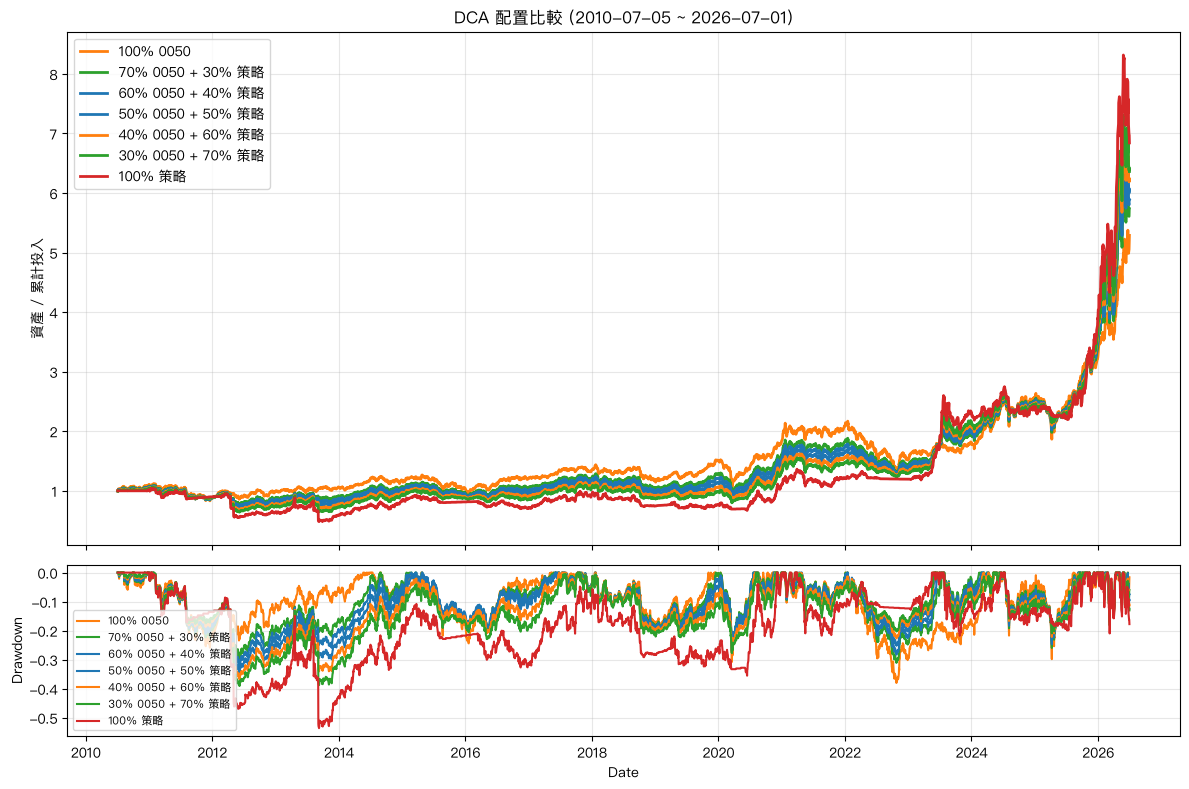

定期定額配置績效比較（主指標：XIRR）


,配置,0050,策略,xirr,total_return,max_dd,calmar
0,100% 0050,100%,0%,18.56%,428.91%,-34.04%,0.55
1,70% 0050 + 30% 策略,70%,30%,19.41%,473.74%,-26.68%,0.73
2,60% 0050 + 40% 策略,60%,40%,19.69%,489.47%,-24.90%,0.79
3,50% 0050 + 50% 策略,50%,50%,19.97%,505.12%,-23.35%,0.86
4,40% 0050 + 60% 策略,40%,60%,20.23%,520.65%,-24.01%,0.84
5,30% 0050 + 70% 策略,30%,70%,20.49%,536.10%,-27.48%,0.75
6,100% 策略,0%,100%,21.24%,584.18%,-40.58%,0.52



【選比例參考】
  最高 XIRR:       100% 策略 (21.24%)
  最小回撤:       50% 0050 + 50% 策略 (-23.35%)
  最佳 Calmar:     50% 0050 + 50% 策略 (0.86)

💡 預設 70/30 對齊 paper_trading/settings.csv


In [15]:
# ── 定期定額配置比較：100% 0050 / 70-30 / 50-50 / 100% 策略 ──
# 需先執行 Cell10（build_signals, collect_trades）、Cell1（df）
import matplotlib.pyplot as plt
import numpy as np
from backtest_portfolio import market_df_from_stock_table, simulate_portfolio_dca, simulate_0050_dca, DCA_AMOUNT, DCA_START

plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

sig = build_signals(df, daily_scores)
all_trades = collect_trades(sig)
market_df = market_df_from_stock_table(df)

CONFIGS = {
    "100% 0050": None,
    "70% 0050 + 30% 策略": (0.7, 0.3),
    "60% 0050 + 40% 策略": (0.6, 0.4),
    "50% 0050 + 50% 策略": (0.5, 0.5),
    "40% 0050 + 60% 策略": (0.4, 0.6),
    "30% 0050 + 70% 策略": (0.3, 0.7),
    "100% 策略": (0.0, 1.0),
}

curve_df = None
rows = []

for name, weights in CONFIGS.items():
    if weights is None:
        eq, m = simulate_0050_dca(market_df, dca_amount=DCA_AMOUNT, w_0050=1.0, dca_start=DCA_START)
    else:
        eq, m = simulate_portfolio_dca(
            all_trades, sig, market_df,
            dca_amount=DCA_AMOUNT, w_0050=weights[0], w_strategy=weights[1],
            dca_start=DCA_START,
        )
    eq = eq.copy()
    eq["norm"] = eq["equity"] / eq["cumulative_invested"]
    if curve_df is None:
        curve_df = pd.DataFrame({"date": eq["date"]})
    curve_df[name] = eq["norm"].values
    calmar = m["xirr"] / abs(m["max_dd"]) if m["max_dd"] < 0 else np.nan
    w_b = weights[0] if weights else 1.0
    w_s = weights[1] if weights else 0.0
    rows.append({
        "配置": name, "0050": f"{w_b:.0%}", "策略": f"{w_s:.0%}",
        "xirr": m["xirr"], "total_return": m["total_return"],
        "max_dd": m["max_dd"], "calmar": calmar,
        "total_invested": m["total_invested"], "final_equity": m["final_equity"],
    })

blend_summary = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})
colors = {"100% 0050": "C1", "70% 0050 + 30% 策略": "C2",
          "50% 0050 + 50% 策略": "C0", "100% 策略": "C3"}

for name in CONFIGS:
    axes[0].plot(curve_df["date"], curve_df[name], label=name,
                 linewidth=2.0, color=colors.get(name))
axes[0].set_ylabel("資產 / 累計投入")
axes[0].set_title(f"DCA 配置比較 ({curve_df['date'].min().date()} ~ {curve_df['date'].max().date()})")
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

for name in CONFIGS:
    s = curve_df[name]
    dd = s / s.cummax() - 1
    axes[1].plot(curve_df["date"], dd, label=name, linewidth=1.5, color=colors.get(name))
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend(loc="lower left", fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 70)
print("定期定額配置績效比較（主指標：XIRR）")
print("=" * 70)
display(
    blend_summary[["配置", "0050", "策略", "xirr", "total_return", "max_dd", "calmar"]]
    .style.format({
        "xirr": "{:.2%}",
        "total_return": "{:.2%}",
        "max_dd": "{:.2%}",
        "calmar": "{:.2f}",
    })
    .highlight_max(subset=["xirr", "calmar"], color="#d4edda")
    .highlight_min(subset=["max_dd"], color="#d4edda")
)

candidates = blend_summary.copy()
best_xirr = candidates.loc[candidates["xirr"].idxmax()]
best_dd = candidates.loc[candidates["max_dd"].idxmax()]
best_calmar = candidates.loc[candidates["calmar"].idxmax()]

print("\n【選比例參考】")
print(f"  最高 XIRR:       {best_xirr['配置']} ({best_xirr['xirr']:.2%})")
print(f"  最小回撤:       {best_dd['配置']} ({best_dd['max_dd']:.2%})")
print(f"  最佳 Calmar:     {best_calmar['配置']} ({best_calmar['calmar']:.2f})")
print("\n💡 預設 70/30 對齊 paper_trading/settings.csv")




In [16]:
# ── 持仓出场检查（对接 paper_trading/open_positions.csv）──
# 需先执行 Cell 1～3（df、signals）；Cell 12 可不跑
from pathlib import Path

STOP_LOSS_PCT = 0.08
TRAILING_STOP_PCT = 0.10
POSITIONS_CSV = PAPER_DIR / "open_positions.csv"

latest_date = signals["date"].max()
today = signals[signals["date"] == latest_date].copy()


def _norm_stock_id(sid) -> str:
    s = str(sid).strip()
    return s.zfill(4) if s.isdigit() else s


# 今日行情 lookup
_today_px = today.copy()
_today_px["_sid"] = _today_px["stock_id"].astype(str).str.strip()
_today_px.loc[_today_px["_sid"].str.isdigit(), "_sid"] = (
    _today_px.loc[_today_px["_sid"].str.isdigit(), "_sid"].str.zfill(4)
)
_today_by_id = _today_px.set_index("_sid")

if not POSITIONS_CSV.exists():
    print(f"⚠ 找不到 {POSITIONS_CSV}，请先在 paper_trading/ 建立持仓表")
elif POSITIONS_CSV.read_text(encoding="utf-8").strip().count("\n") < 1:
    print("【持仓出场检查】open_positions.csv 尚无持仓")
else:
    positions = pd.read_csv(POSITIONS_CSV)
    if positions.empty or positions["股票代碼"].isna().all():
        print("【持仓出场检查】open_positions.csv 尚无持仓")
    else:
        sell_rows = []
        hold_rows = []
        missing_rows = []

        for _, pos in positions.iterrows():
            code = _norm_stock_id(pos["股票代碼"])
            name = pos.get("股票名稱", "")
            entry = float(pos["買入價"])
            shares = float(pos["股數"])
            high = float(pos.get("持倉最高價", entry) or entry)

            if code not in _today_by_id.index:
                missing_rows.append({"股票代碼": code, "股票名稱": name})
                continue

            row = _today_by_id.loc[code]
            close = float(row["close"])
            high = max(high, close)
            ret = close / entry - 1
            stop_loss = ret <= -STOP_LOSS_PCT
            trailing = close < high * (1 - TRAILING_STOP_PCT)
            trend_exit = bool(row["sell_signal"])

            reasons = []
            if stop_loss:
                reasons.append("stop_loss (-8%)")
            if trailing:
                reasons.append("trailing_stop (-10%)")
            if trend_exit:
                reasons.append("sell_signal")

            rec = {
                "股票代碼": code,
                "股票名稱": name,
                "買入價": entry,
                "現價": close,
                "報酬率": f"{ret:.2%}",
                "持倉最高價": high,
                "sell_signal": trend_exit,
                "固定停損": stop_loss,
                "移動停損": trailing,
            }

            if reasons:
                rec["賣出原因"] = " + ".join(reasons)
                sell_rows.append(rec)
            else:
                rec["狀態"] = "继续持有"
                hold_rows.append(rec)

        print(f"\n{'='*60}")
        print(f"【持仓出场检查】资料日 {latest_date.date()}  |  持仓 {len(positions)} 档")
        print(f"{'='*60}")

        if sell_rows:
            sell_df = pd.DataFrame(sell_rows)
            print(f"\n🔴 明日 T+1 建议卖出 — 共 {len(sell_df)} 档")
            display(sell_df[[
                "股票代碼", "股票名稱", "買入價", "現價", "報酬率",
                "持倉最高價", "賣出原因",
            ]])
        else:
            print("\n🟢 今日无出场信号 — 全部持仓继续持有")

        if hold_rows:
            hold_df = pd.DataFrame(hold_rows)
            print(f"\n🟡 继续持有 — 共 {len(hold_df)} 档")
            display(hold_df[[
                "股票代碼", "股票名稱", "買入價", "現價", "報酬率", "持倉最高價", "狀態",
            ]])

        if missing_rows:
            miss_df = pd.DataFrame(missing_rows)
            print(f"\n⚠ 以下持仓找不到今日行情（请更新 fetch_tw50_stock_data.ipynb 资料）")
            display(miss_df)

        # 更新 open_positions.csv 的持仓最高价
        if sell_rows or hold_rows:
            updated = positions.copy()
            for i, pos in updated.iterrows():
                code = _norm_stock_id(pos["股票代碼"])
                if code in _today_by_id.index:
                    old_high = float(pos.get("持倉最高價", pos["買入價"]) or pos["買入價"])
                    updated.at[i, "持倉最高價"] = max(old_high, float(_today_by_id.loc[code]["close"]))
            updated.to_csv(POSITIONS_CSV, index=False, encoding="utf-8-sig")
            print(f"\n✅ 已更新 {POSITIONS_CSV.name} 的「持倉最高價」")

        print("\n💡 卖出后：transactions.csv 记一笔「卖 / 策略」，并从 open_positions.csv 删除该档")


【持仓出场检查】资料日 2026-07-01  |  持仓 4 档

🟢 今日无出场信号 — 全部持仓继续持有

🟡 继续持有 — 共 4 档


,股票代碼,股票名稱,買入價,現價,報酬率,持倉最高價,狀態
0,2344,華邦電,205.5,190.0,-7.54%,207.5,继续持有
1,2408,南亞科,449.0,421.0,-6.24%,453.0,继续持有
2,2303,聯電,167.0,169.0,1.20%,169.0,继续持有
3,1303,南亞,183.0,183.0,0.00%,183.0,继续持有



✅ 已更新 open_positions.csv 的「持倉最高價」

💡 卖出后：transactions.csv 记一笔「卖 / 策略」，并从 open_positions.csv 删除该档
